### 1. IMPORTAR LIBRERÍAS

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from PIL import Image
from collections import Counter

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


### 2. PARÁMETROS

In [2]:
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 15
NUM_CLASSES   = 38
NOMBRE_MODELO = 'plantvillage_resnet50'

PATIENCE_ES = 8
PATIENCE_LR = 4

### 3. PREPROCESAMIENTO

In [3]:
base_dir = '../../../Data/PlantVillage'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'Imágenes de entrenamiento : {train_generator.samples}')
print(f'Imágenes de validación    : {val_generator.samples}')
print(f'Imágenes de test          : {test_generator.samples}')

Found 43471 images belonging to 38 classes.
Found 5417 images belonging to 38 classes.
Found 5417 images belonging to 38 classes.
Imágenes de entrenamiento : 43471
Imágenes de validación    : 5417
Imágenes de test          : 5417


### 4. CONSTRUCCIÓN DEL MODELO

In [4]:
# weights=None → empieza desde cero, sin ImageNet
base_model = ResNet50(
    weights=None,
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name=NOMBRE_MODELO)

model.summary()

Model: "plantvillage_resnet50"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 38)                4902      
                                                                 
Total params: 23,854,886
Trainable params: 23,801,766
Non-trainable params: 53,120
____________________________

### 5. COMPILAR EL MODELO

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 6. ENTRENAMIENTO

In [6]:
os.makedirs('../pesos_resnet50', exist_ok=True)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE_ES,
    restore_best_weights=True,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='../pesos_resnet50/resnet50_plantvillage_weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=PATIENCE_LR,
    min_lr=1e-6,
    verbose=1
)

print("Iniciando entrenamiento en PlantVillage...")
print("Esto puede tardar muchas horas en CPU. No cierres Jupyter.\n")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

Iniciando entrenamiento en PlantVillage...
Esto puede tardar muchas horas en CPU. No cierres Jupyter.

Epoch 1/15
1359/1359 [==============================] - ETA: 0s - loss: 2.8343 - accuracy: 0.2536
Epoch 1: val_loss improved from inf to 2.36692, saving model to ../pesos_resnet50\resnet50_plantvillage_weights.h5
1359/1359 [==============================] - 6596s 5s/step - loss: 2.8343 - accuracy: 0.2536 - val_loss: 2.3669 - val_accuracy: 0.3485 - lr: 0.0010
Epoch 2/15
1359/1359 [==============================] - ETA: 0s - loss: 2.4903 - accuracy: 0.3150
Epoch 2: val_loss improved from 2.36692 to 2.21478, saving model to ../pesos_resnet50\resnet50_plantvillage_weights.h5
1359/1359 [==============================] - 6585s 5s/step - loss: 2.4903 - accuracy: 0.3150 - val_loss: 2.2148 - val_accuracy: 0.4019 - lr: 0.0010
Epoch 3/15
1359/1359 [==============================] - ETA: 0s - loss: 2.2579 - accuracy: 0.3668
Epoch 3: val_loss did not improve from 2.21478
1359/1359 [===============

### 7. GUARDAR PESOS DEL BACKBONE

In [7]:
base_model.save_weights('../pesos_resnet50/resnet50_backbone_plantvillage.h5')
print("Pesos del backbone guardados en:")
print("../pesos_resnet50/resnet50_backbone_plantvillage.h5")

Pesos del backbone guardados en:
../pesos_resnet50/resnet50_backbone_plantvillage.h5


### 8. CURVAS DE ENTRENAMIENTO

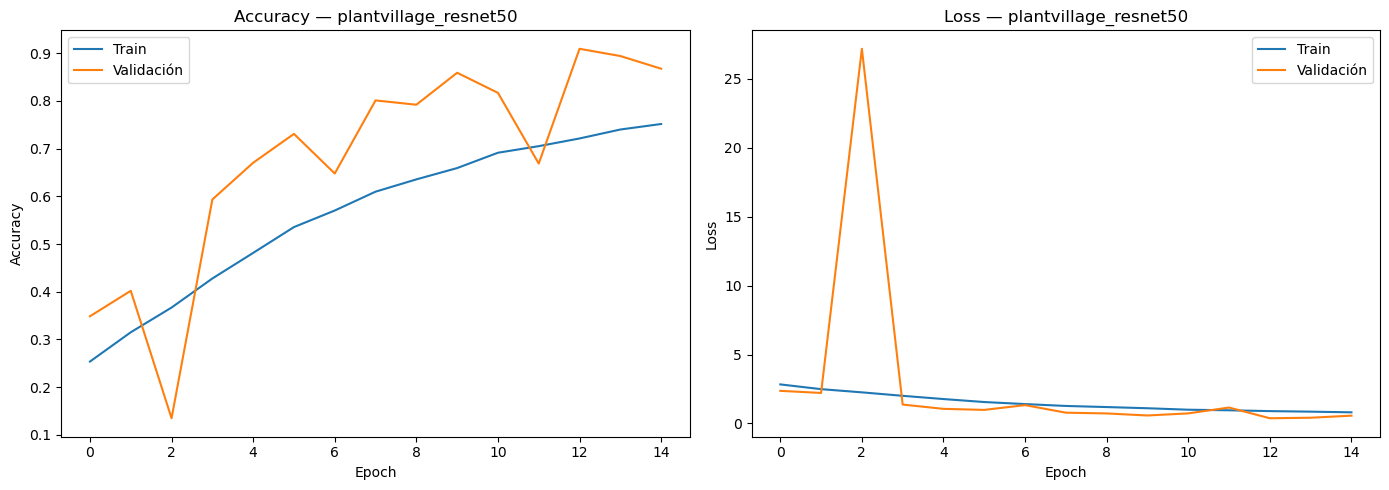

Mejor val_accuracy: 0.9092


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validación')
ax1.set_title(f'Accuracy — {NOMBRE_MODELO}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validación')
ax2.set_title(f'Loss — {NOMBRE_MODELO}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig('../pesos_resnet50/curvas_resnet50_plantvillage.png', dpi=150)
plt.show()

print(f'Mejor val_accuracy: {max(history.history["val_accuracy"]):.4f}')

### 9. EVALUCACIÓN EN TEST

In [9]:
test_generator.reset()

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

predicciones = model.predict(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE + 1
)
y_pred = np.argmax(predicciones, axis=1)
y_true = test_generator.classes

f1 = f1_score(y_true, y_pred, average='weighted')

print(f'\nTest Accuracy : {test_accuracy:.4f}')
print(f'Test Loss     : {test_loss:.4f}')
print(f'F1 Score      : {f1:.4f}')

nombres_clases = list(test_generator.class_indices.keys())
print('\n--- Reporte de clasificación ---')
print(classification_report(y_true, y_pred, target_names=nombres_clases))

170/170 [==============================] - 283s 2s/step

Test Accuracy : 0.8652
Test Loss     : 0.4730
F1 Score      : 0.8568

--- Reporte de clasificación ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.81      0.54      0.65        63
                                 Apple___Black_rot       0.94      0.27      0.42        62
                          Apple___Cedar_apple_rust       1.00      0.56      0.71        27
                                   Apple___healthy       0.90      0.74      0.81       164
                               Blueberry___healthy       0.72      0.99      0.83       150
          Cherry_(including_sour)___Powdery_mildew       0.92      0.92      0.92       105
                 Cherry_(including_sour)___healthy       0.90      0.44      0.59        85
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.00      0.00      0.00        51
           

c:\ProgramData\anaconda3\envs\tesis_cana\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\envs\tesis_cana\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\envs\tesis_cana\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r